# Importing Libraries and Reaading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pypalettes import load_palette
from pypalettes import load_cmap

In [2]:
df = pd.read_sas('LLCP2024.XPT')

In [3]:
df.head(10)

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
5,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000006',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
6,1.0,2.0,b'02262024',b'02',b'26',b'2024',1100.0,b'2024000007',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,1.0,2.0
7,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000008',2.024000e+09,1.0,...,2.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,1.0,2.0
8,1.0,2.0,b'02202024',b'02',b'20',b'2024',1100.0,b'2024000009',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,1.0
9,1.0,2.0,b'02262024',b'02',b'26',b'2024',1100.0,b'2024000010',2.024000e+09,1.0,...,1.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0


# Filtering Columns and Mapping Them Back

In [4]:
demographic_columns = ['MARITAL', 'EDUCA', 'EMPLOY1', 'INCOME3', 'CHILDREN', '_BMI5', '_URBSTAT', '_IMPRACE', '_AGE_G', 'SEXVAR']

target_column = 'DIABETE4'

In [5]:
df_eda = df[demographic_columns]

In [6]:
df_eda['DIABETE4'] = df['DIABETE4'].copy()

In [7]:
df_eda

,MARITAL,EDUCA,EMPLOY1,INCOME3,CHILDREN,_BMI5,_URBSTAT,_IMPRACE,_AGE_G,SEXVAR,DIABETE4
0,3.0,4.0,7.0,99.0,88.0,2249.0,1.0,1.0,6.0,2.0,3.0
1,1.0,6.0,7.0,11.0,88.0,2583.0,1.0,1.0,6.0,1.0,3.0
2,6.0,5.0,1.0,99.0,88.0,2253.0,1.0,1.0,5.0,1.0,3.0
3,1.0,6.0,7.0,6.0,88.0,2509.0,1.0,1.0,6.0,1.0,3.0
4,5.0,5.0,8.0,3.0,88.0,1977.0,1.0,1.0,4.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
457665,1.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,6.0,1.0,3.0
457666,5.0,2.0,1.0,6.0,88.0,2066.0,NaN,2.0,6.0,1.0,3.0
457667,5.0,6.0,7.0,8.0,88.0,2437.0,NaN,2.0,6.0,1.0,1.0
457668,1.0,5.0,2.0,10.0,88.0,2441.0,NaN,1.0,4.0,1.0,3.0


In [8]:
marital_map = {
    1: 'Married', 
    2: 'Divorced', 
    3: 'Widowed', 
    4: 'Separated', 
    5: 'Never Married', 
    6: 'Unmarried Couple',
    9: 'Refused'
}

educa_map = {
    1: 'Kindergarten/None', 
    2: 'Elementary', 
    3: 'Some High School', 
    4: 'High School Grad', 
    5: 'Some College', 
    6: 'College Grad',
    9: 'Refused'
}

employ1_map = {
    1: 'Employed', 
    2: 'Self-employed', 
    3: 'Out of work > 1 yr', 
    4: 'Out of work < 1 yr', 
    5: 'Homemaker', 
    6: 'Student', 
    7: 'Retired', 
    8: 'Unable to work',
    9: 'Refused'
}

#otherwise it will treat is as latex >:(
income3_map = {
    1: '< \$10k', 
    2: '\$10k - \$15k', 
    3: '\$15k - \$20k', 
    4: '\$20k - \$25k', 
    5: '\$25k - \$35k', 
    6: '\$35k - \$50k', 
    7: '\$50k - \$75k', 
    8: '\$75k - \$100k', 
    9: '\$100k - \$150k', 
    10: '\$150k - \$200k', 
    11: '>= \$200k', 
    77: 'Not Sure', 
    99: 'Refused'
}

urbstat_map = {
    1: 'Urban', 
    2: 'Rural'
}

imprace_map = {
    1: 'White', 
    2: 'Black', 
    3: 'Asian', 
    4: 'AI/AN',
    5: 'Hispanic', 
    6: 'Other'
}

diabete4_map = {
    1: 'Diabetes', 
    2: np.nan, 
    3: 'Healthy', 
    4: 'Diabetes', 
    7: np.nan, 
    9: np.nan
}

age_map = {
    1: '18-24',
    2: '25-34',
    3: '35-44',
    4: '45-54',
    5: '55-64',
    6: '65+'
}

sex_map = {
    1: 'Male',
    2: 'Female'
}

# 2. Terapkan ke DataFrame



df_eda['MARITAL'] = df['MARITAL'].map(marital_map)
df_eda['EDUCA'] = df['EDUCA'].map(educa_map)
df_eda['EMPLOY1'] = df['EMPLOY1'].map(employ1_map)
df_eda['INCOME3'] = df['INCOME3'].map(income3_map)
df_eda['_URBSTAT'] = df['_URBSTAT'].map(urbstat_map)
df_eda['CHILDREN'] = df['CHILDREN'].replace({
    88: 0,
    99: np.nan
})
df_eda['_BMI5'] = df_eda['_BMI5'] / 100
df_eda['_IMPRACE'] = df['_IMPRACE'].map(imprace_map)
df_eda['DIABETE4'] = df['DIABETE4'].map(diabete4_map)
df_eda['_AGE_G'] = df_eda['_AGE_G'].map(age_map)
df_eda['SEXVAR'] = df_eda['SEXVAR'].map(sex_map)

<>:35: SyntaxWarning: invalid escape sequence '\$'
<>:36: SyntaxWarning: invalid escape sequence '\$'
<>:37: SyntaxWarning: invalid escape sequence '\$'
<>:38: SyntaxWarning: invalid escape sequence '\$'
<>:39: SyntaxWarning: invalid escape sequence '\$'
<>:40: SyntaxWarning: invalid escape sequence '\$'
<>:41: SyntaxWarning: invalid escape sequence '\$'
<>:42: SyntaxWarning: invalid escape sequence '\$'
<>:43: SyntaxWarning: invalid escape sequence '\$'
<>:44: SyntaxWarning: invalid escape sequence '\$'
<>:45: SyntaxWarning: invalid escape sequence '\$'
<>:35: SyntaxWarning: invalid escape sequence '\$'
<>:36: SyntaxWarning: invalid escape sequence '\$'
<>:37: SyntaxWarning: invalid escape sequence '\$'
<>:38: SyntaxWarning: invalid escape sequence '\$'
<>:39: SyntaxWarning: invalid escape sequence '\$'
<>:40: SyntaxWarning: invalid escape sequence '\$'
<>:41: SyntaxWarning: invalid escape sequence '\$'
<>:42: SyntaxWarning: invalid escape sequence '\$'
<>:43: SyntaxWarning: invalid e

In [9]:
df_eda.head()

,MARITAL,EDUCA,EMPLOY1,INCOME3,CHILDREN,_BMI5,_URBSTAT,_IMPRACE,_AGE_G,SEXVAR,DIABETE4
0,Widowed,High School Grad,Retired,Refused,0.0,22.49,Urban,White,65+,Female,Healthy
1,Married,College Grad,Retired,>= \$200k,0.0,25.83,Urban,White,65+,Male,Healthy
2,Unmarried Couple,Some College,Employed,Refused,0.0,22.53,Urban,White,55-64,Male,Healthy
3,Married,College Grad,Retired,\$35k - \$50k,0.0,25.09,Urban,White,65+,Male,Healthy
4,Never Married,Some College,Unable to work,\$15k - \$20k,0.0,19.77,Urban,White,45-54,Male,Healthy


# Basic Statistics

In [10]:
df_eda.isna().sum()

MARITAL         9
EDUCA           7
EMPLOY1      3303
INCOME3      9269
CHILDREN     9379
_BMI5       43037
_URBSTAT    14623
_IMPRACE        0
_AGE_G          0
SEXVAR          0
DIABETE4     4429
dtype: int64

Thats a lot of missing values, but iirc we have like 400k+ data, so I think we are fine. Let's check the data shape to see whether its safe to drop these columns or not

In [11]:
df_eda.shape

(457670, 11)

Yep, we are fine, especially in EDA where the focus is to plot out trends first, not modelling yet.

In [12]:
df_eda.dropna(inplace=True)

In [13]:
df_eda.shape

(395780, 11)

That is still a lot of data, hell yeah.

In [14]:
df_eda.describe()

,CHILDREN,_BMI5
count,395780.000000,395780.000000
mean,0.470223,28.551850
std,1.111298,6.582902
min,0.000000,12.000000
25%,0.000000,24.140000
50%,0.000000,27.440000
75%,0.000000,31.750000
max,83.000000,99.840000


What? does a family really have 83 childrens??

In [15]:
df_eda.info()

<class 'pandas.DataFrame'>
Index: 395780 entries, 0 to 450352
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   MARITAL   395780 non-null  str    
 1   EDUCA     395780 non-null  str    
 2   EMPLOY1   395780 non-null  str    
 3   INCOME3   395780 non-null  str    
 4   CHILDREN  395780 non-null  float64
 5   _BMI5     395780 non-null  float64
 6   _URBSTAT  395780 non-null  str    
 7   _IMPRACE  395780 non-null  str    
 8   _AGE_G    395780 non-null  str    
 9   SEXVAR    395780 non-null  str    
 10  DIABETE4  395780 non-null  str    
dtypes: float64(2), str(9)
memory usage: 62.9 MB


# EDA

## EDA Setup

In [16]:
df_eda.columns

Index(['MARITAL', 'EDUCA', 'EMPLOY1', 'INCOME3', 'CHILDREN', '_BMI5',
       '_URBSTAT', '_IMPRACE', '_AGE_G', 'SEXVAR', 'DIABETE4'],
      dtype='str')

In [17]:
neon_cmap = load_cmap('Neon')
neon_colors = neon_cmap.colors

sns.set_palette(sns.color_palette(neon_colors))

custom_rc_dark = {
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "savefig.facecolor": "none",
    
    "text.color": "#FFFFFF",
    "axes.labelcolor": "#FFFFFF",
    "xtick.color": "#FFFFFF",
    "ytick.color": "#FFFFFF",
    "axes.edgecolor": "#FFFFFF", 
    
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    
    "axes.grid.axis": "y",
    "grid.color": "#FFFFFF",
    "grid.alpha": 0.2,
    "grid.linestyle": "--",
    
    "font.family": "sans-serif",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
}

sns.set_context("talk", rc=custom_rc_dark)
plt.rcParams.update(custom_rc_dark)

## Diabetes Distrbution

/tmp/ipykernel_62019/2270463192.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


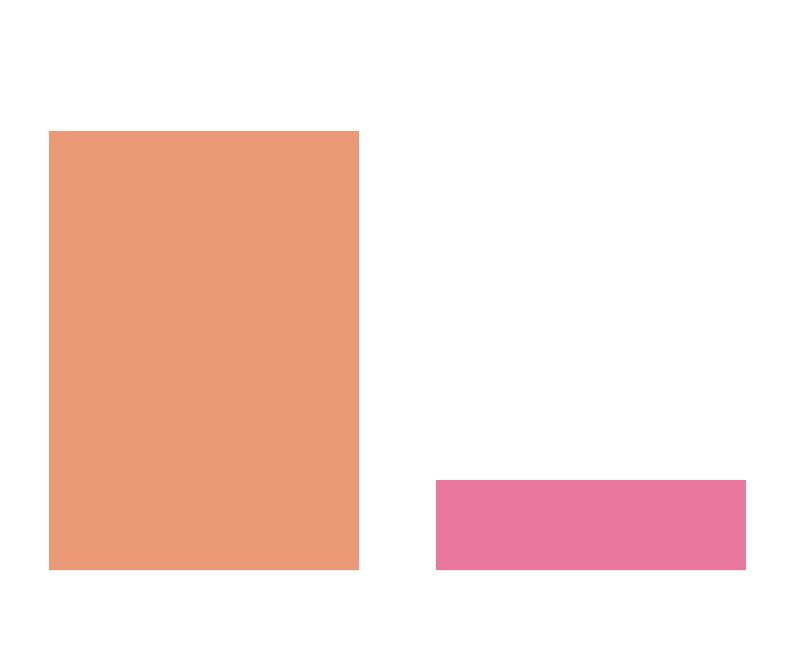

In [18]:
target_counts = df_eda['DIABETE4'].value_counts().reset_index()
target_counts.columns = ['DIABETE4', 'Jumlah']

total_responden = target_counts['Jumlah'].sum()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='DIABETE4', 
    y='Jumlah', 
    data=target_counts,
    palette=neon_colors[:len(target_counts)]
)

for p in ax.patches:
    height = p.get_height()
    persentase = (height / total_responden) * 100
    
    label_text = f"{int(height):,}\n({persentase:.1f}%)"
    
    ax.annotate(label_text, 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='#FFFFFF',
                xytext=(0, 8), textcoords='offset points')

plt.title('Distribusi Status Diabetes Responden', 
          fontsize=16, weight='bold', pad=60, color='#FFFFFF')
plt.xlabel('Status Diagnosis', fontsize=12, weight='bold', labelpad=15, color='#FFFFFF')

ax.set_yticks([]) 
ax.set_ylabel('') 

ax.spines['left'].set_visible(False)

plt.tight_layout

plt.savefig('./outputs/demographic/ar_distribusi_target_ppt.png', transparent=True, dpi=300, bbox_inches='tight')

## Categorical

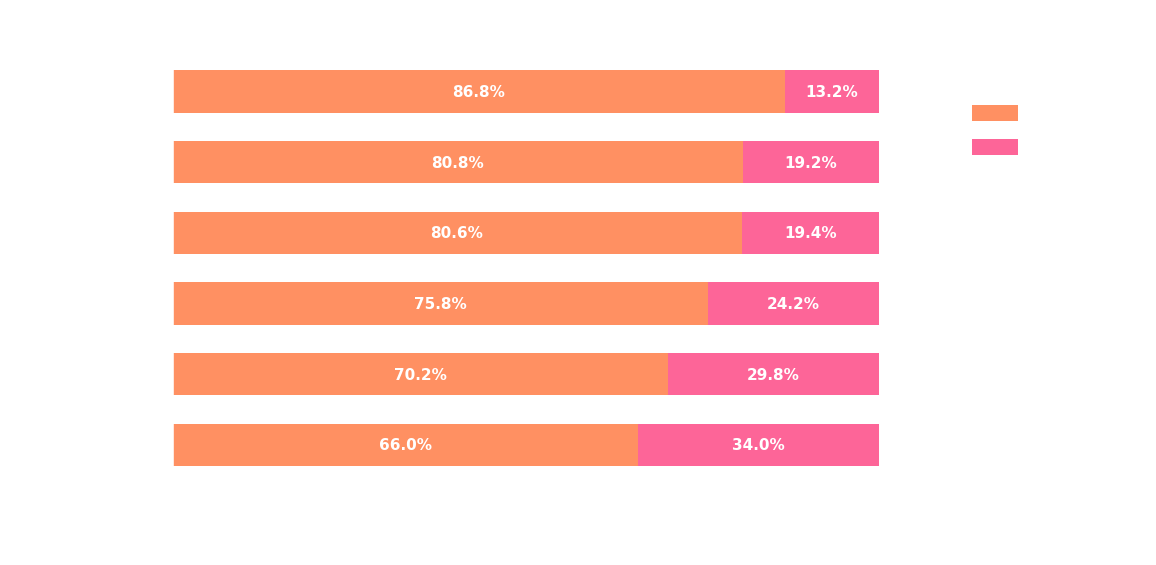

In [19]:
educa_order = ['Kindergarten/None', 'Elementary', 'Some High School', 
               'High School Grad', 'Some College', 'College Grad']

df_plot = df_eda[df_eda['EDUCA'].isin(educa_order)].copy()

crosstab_educa = pd.crosstab(df_plot['EDUCA'], df_plot['DIABETE4'], normalize='index') * 100

crosstab_educa = crosstab_educa.reindex(educa_order)


kategori_target = ['Healthy','Diabetes'] 
crosstab_educa = crosstab_educa[kategori_target]

fig, ax = plt.subplots(figsize=(12, 6))

crosstab_educa.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Tingkat Pendidikan', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('')

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)


plt.tight_layout()

plt.savefig('./outputs/demographic/bivariat_pendidikan_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()



<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '

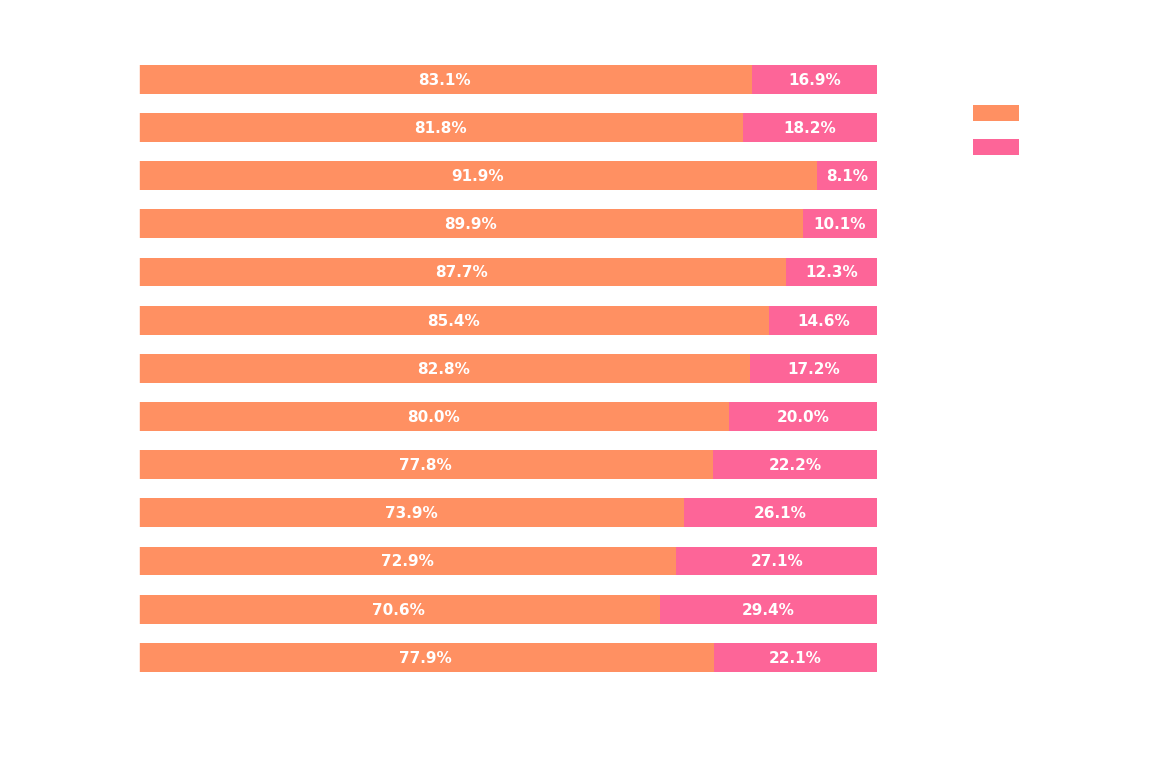

In [20]:
income_order = [
    '< \$10k', 
    '\$10k - \$15k', 
    '\$15k - \$20k', 
    '\$20k - \$25k', 
    '\$25k - \$35k', 
    '\$35k - \$50k', 
    '\$50k - \$75k', 
    '\$75k - \$100k', 
    '\$100k - \$150k', 
    '\$150k - \$200k', 
    '>= \$200k', 
    'Not Sure', 
    'Refused'
]

df_plot_inc = df_eda[df_eda['INCOME3'].isin(income_order)].copy()

crosstab_income = pd.crosstab(df_plot_inc['INCOME3'], df_plot_inc['DIABETE4'], normalize='index') * 100
crosstab_income = crosstab_income.reindex(income_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_income = crosstab_income[kategori_target]

fig, ax = plt.subplots(figsize=(12, 8))

crosstab_income.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Tingkat Pendapatan', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)


plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_pendapatan_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

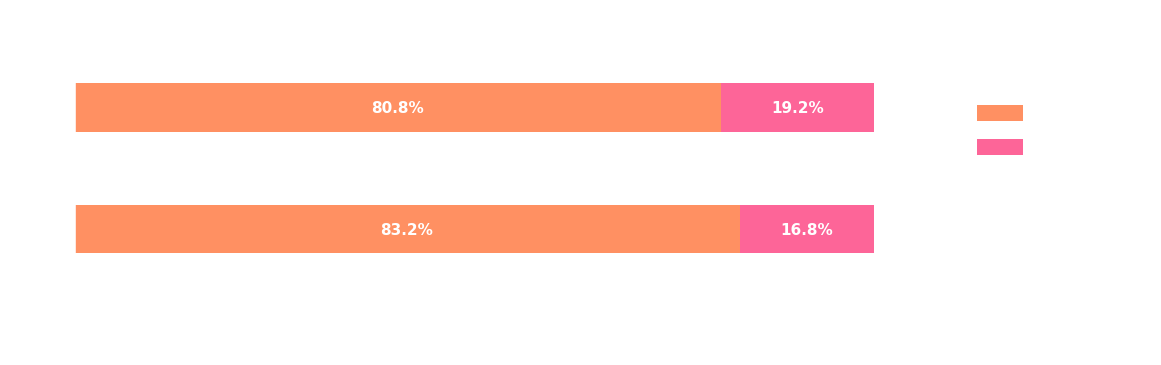

In [21]:
urban_order = ['Urban', 'Rural']

df_plot_urb = df_eda[df_eda['_URBSTAT'].isin(urban_order)].copy()

crosstab_urban = pd.crosstab(df_plot_urb['_URBSTAT'], df_plot_urb['DIABETE4'], normalize='index') * 100
crosstab_urban = crosstab_urban.reindex(urban_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_urban = crosstab_urban[kategori_target]

fig, ax = plt.subplots(figsize=(12, 4))

crosstab_urban.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.4)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Wilayah (Urban vs Rural)', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_urban_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

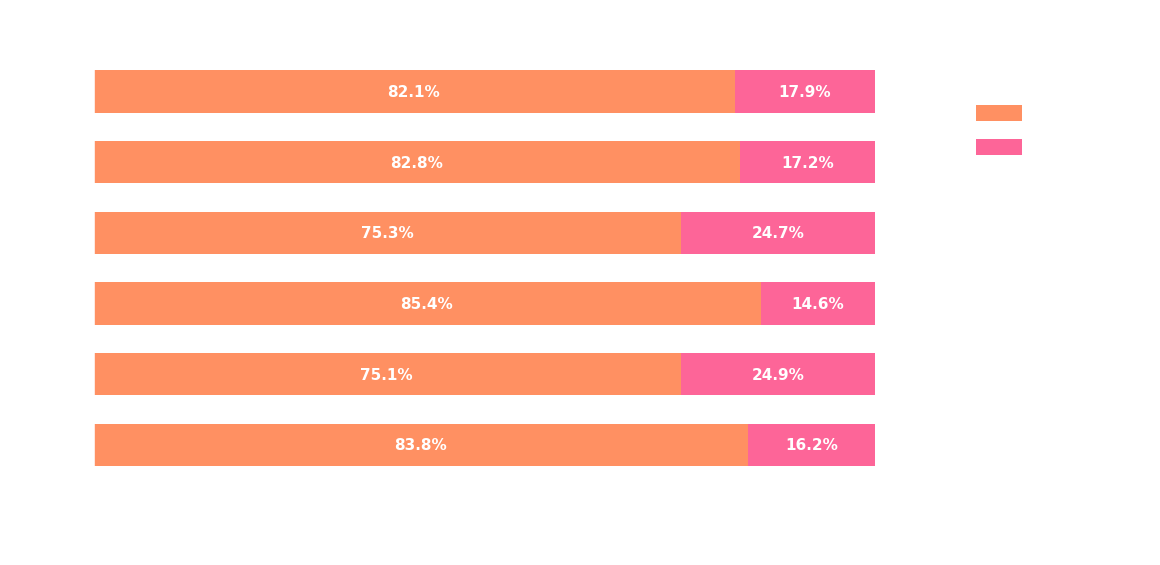

In [22]:
race_order = ['White', 'Black', 'Asian', 'AI/AN', 'Hispanic', 'Other']

df_plot_race = df_eda[df_eda['_IMPRACE'].isin(race_order)].copy()

crosstab_race = pd.crosstab(df_plot_race['_IMPRACE'], df_plot_race['DIABETE4'], normalize='index') * 100
crosstab_race = crosstab_race.reindex(race_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_race = crosstab_race[kategori_target]

fig, ax = plt.subplots(figsize=(12, 6))

crosstab_race.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Ras/Etnis', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_ras_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

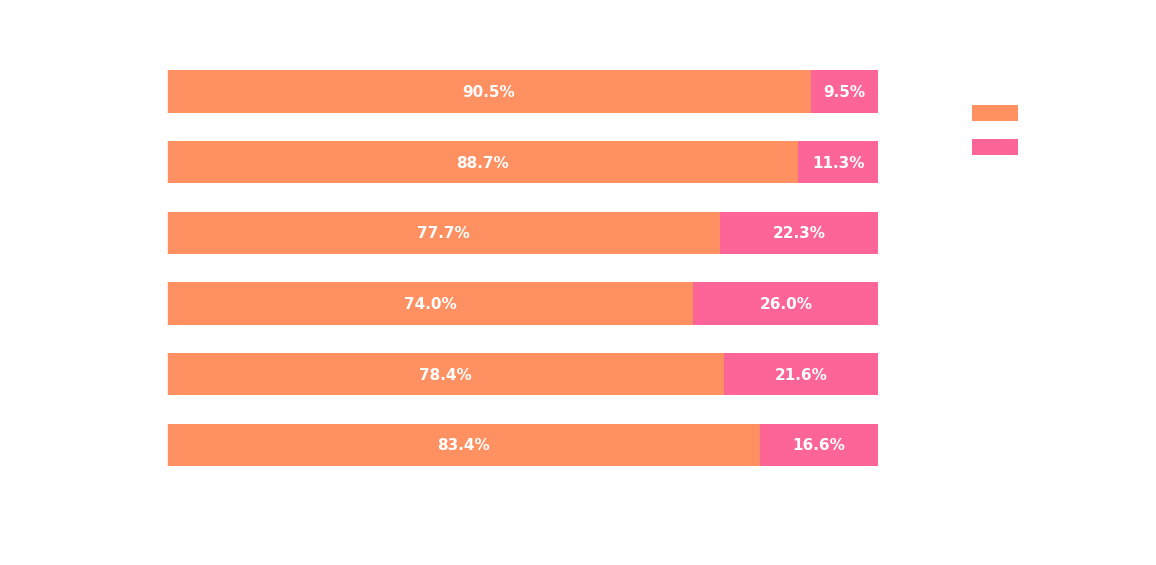

In [23]:
marital_order = ['Married', 'Divorced', 'Widowed', 'Separated', 'Never Married', 'Unmarried Couple']

df_plot_marital = df_eda[df_eda['MARITAL'].isin(marital_order)].copy()

crosstab_marital = pd.crosstab(df_plot_marital['MARITAL'], df_plot_marital['DIABETE4'], normalize='index') * 100
crosstab_marital = crosstab_marital.reindex(marital_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_marital = crosstab_marital[kategori_target]

fig, ax = plt.subplots(figsize=(12, 6))

crosstab_marital.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Status Pernikahan', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_marital_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

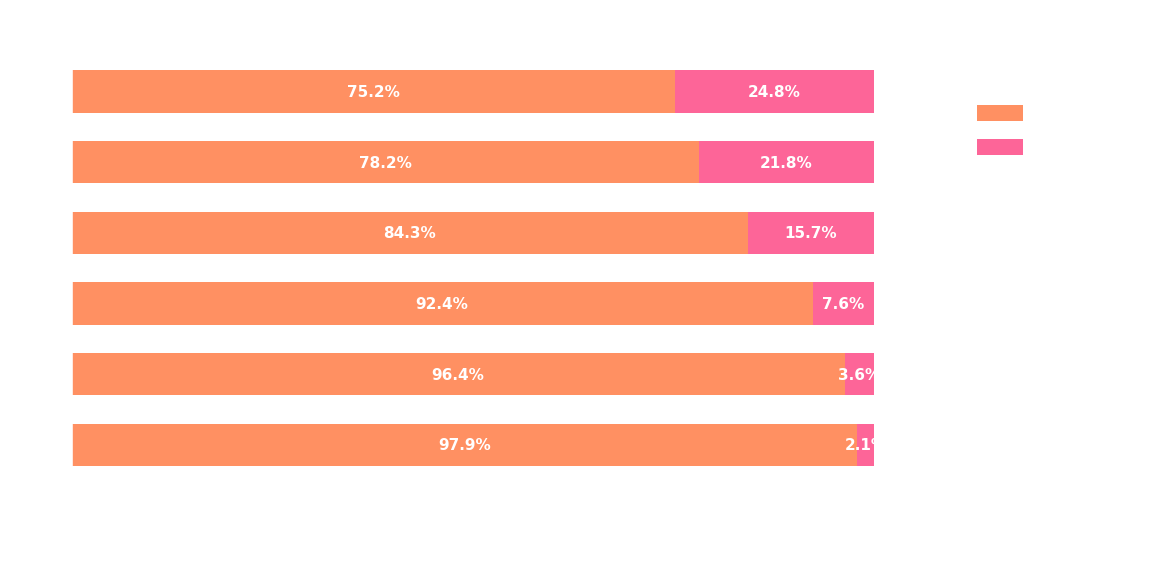

In [24]:
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_plot_age = df_eda[df_eda['_AGE_G'].isin(age_order)].copy()

crosstab_age = pd.crosstab(df_plot_age['_AGE_G'], df_plot_age['DIABETE4'], normalize='index') * 100
crosstab_age = crosstab_age.reindex(age_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_age = crosstab_age[kategori_target]

fig, ax = plt.subplots(figsize=(12, 6))

crosstab_age.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    x = p.get_x() + (width / 2)
    y = p.get_y() + (p.get_height() / 2)
    ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Kelompok Usia', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_age_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

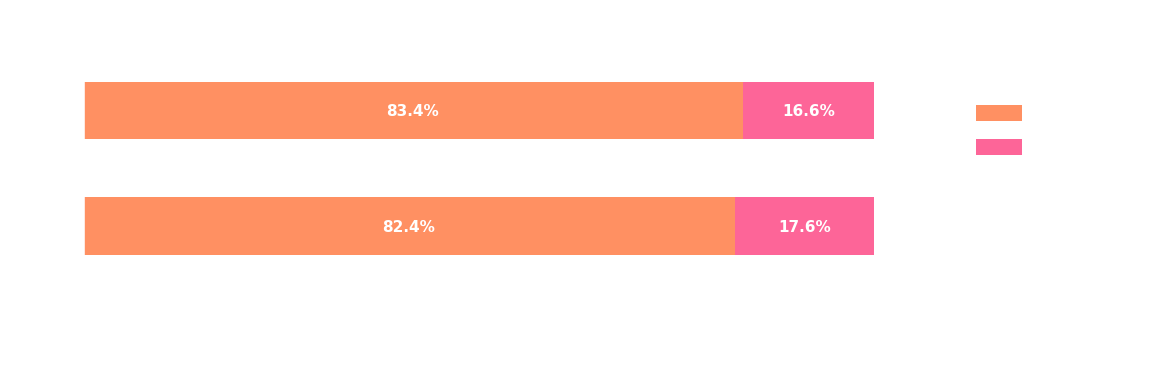

In [25]:
sex_order = ['Male', 'Female']
df_plot_sex = df_eda[df_eda['SEXVAR'].isin(sex_order)].copy()

crosstab_sex = pd.crosstab(df_plot_sex['SEXVAR'], df_plot_sex['DIABETE4'], normalize='index') * 100
crosstab_sex = crosstab_sex.reindex(sex_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_sex = crosstab_sex[kategori_target]

fig, ax = plt.subplots(figsize=(12, 4))

crosstab_sex.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.5)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Jenis Kelamin', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('bivariat_sex_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

## Numerical

/tmp/ipykernel_62019/3260612073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_62019/3260612073.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(


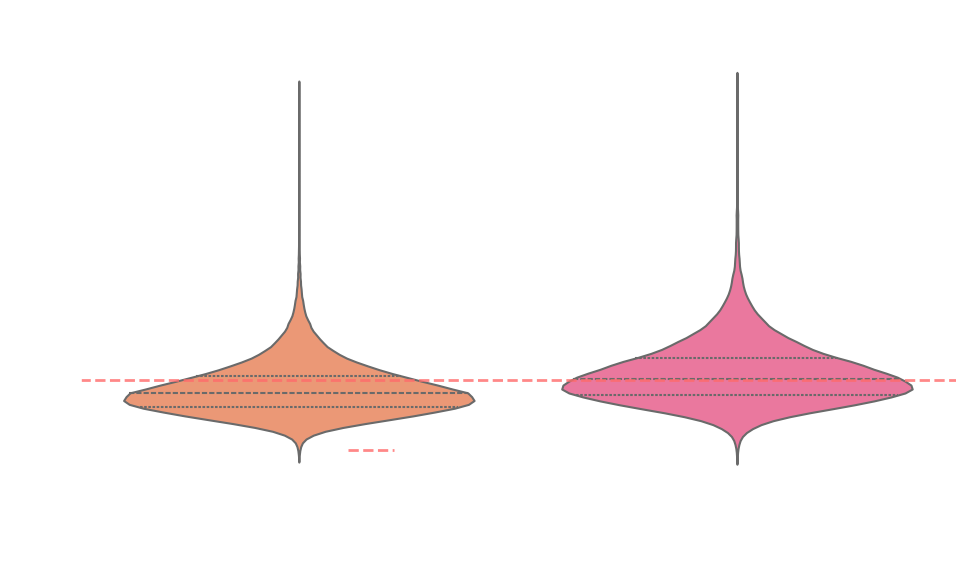

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df_eda, 
    x='DIABETE4', 
    y='_BMI5', 
    palette=neon_colors[:3],
    inner='quartile',
    linewidth=1.5,
    ax=ax
)

plt.title('Distribusi BMI Berdasarkan Status Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Status Diagnosis', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Body Mass Index (BMI)', fontsize=12, weight='bold', color='#FFFFFF')

plt.axhline(y=30, color='#FF6B6B', linestyle='--', linewidth=2, alpha=0.8, label='Batas Obesitas (BMI 30)')

plt.legend(facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF')


plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_bmi_violin_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

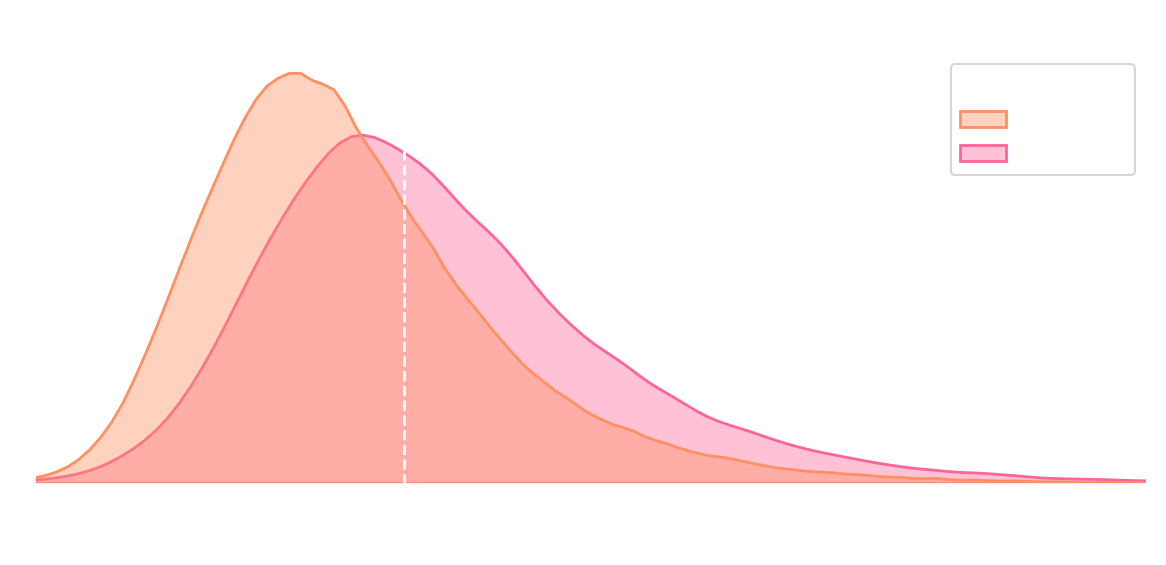

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(
    data=df_eda, 
    x='_BMI5', 
    hue='DIABETE4', 
    fill=True, 
    common_norm=False,
    palette=neon_colors[:df_eda['DIABETE4'].nunique()],
    alpha=0.4,
    linewidth=2,
    ax=ax
)

plt.title('Pergeseran Kepadatan BMI: Sehat vs Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Body Mass Index (BMI)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Kepadatan Populasi', fontsize=12, weight='bold', color='#FFFFFF')

plt.axvline(x=30, color='#FFFFFF', linestyle='--', linewidth=2, label='Batas Obesitas (BMI 30)')

plt.xlim(15, 60) 

ax.set_yticks([])

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_bmi_kde_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

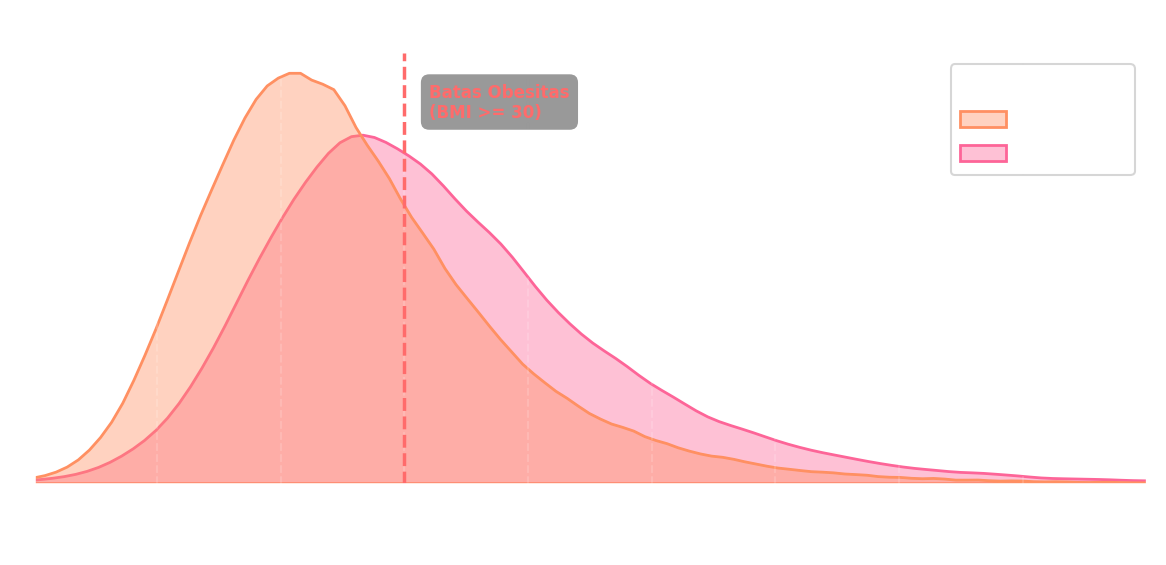

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(
    data=df_eda, 
    x='_BMI5', 
    hue='DIABETE4', 
    fill=True, 
    common_norm=False, 
    palette=neon_colors[:df_eda['DIABETE4'].nunique()],
    alpha=0.4,
    linewidth=2,
    ax=ax
)

plt.title('Pergeseran Kepadatan BMI: Sehat vs Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Body Mass Index (BMI)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Kepadatan Populasi', fontsize=12, weight='bold', color='#FFFFFF')

plt.axvline(x=30, color='#FF6B6B', linestyle='--', linewidth=2.5)

y_max = ax.get_ylim()[1]
ax.text(31, y_max * 0.85, 'Batas Obesitas\n(BMI >= 30)', 
        color='#FF6B6B', fontsize=12, weight='bold', 
        bbox=dict(facecolor='#000000', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.5'))

plt.xlim(15, 60) 
ax.set_yticks([])

ax.grid(True, axis='x', color='#FFFFFF', alpha=0.15, linestyle='--')

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_bmi_kde_grid_ppt_2.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_62019/342231785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


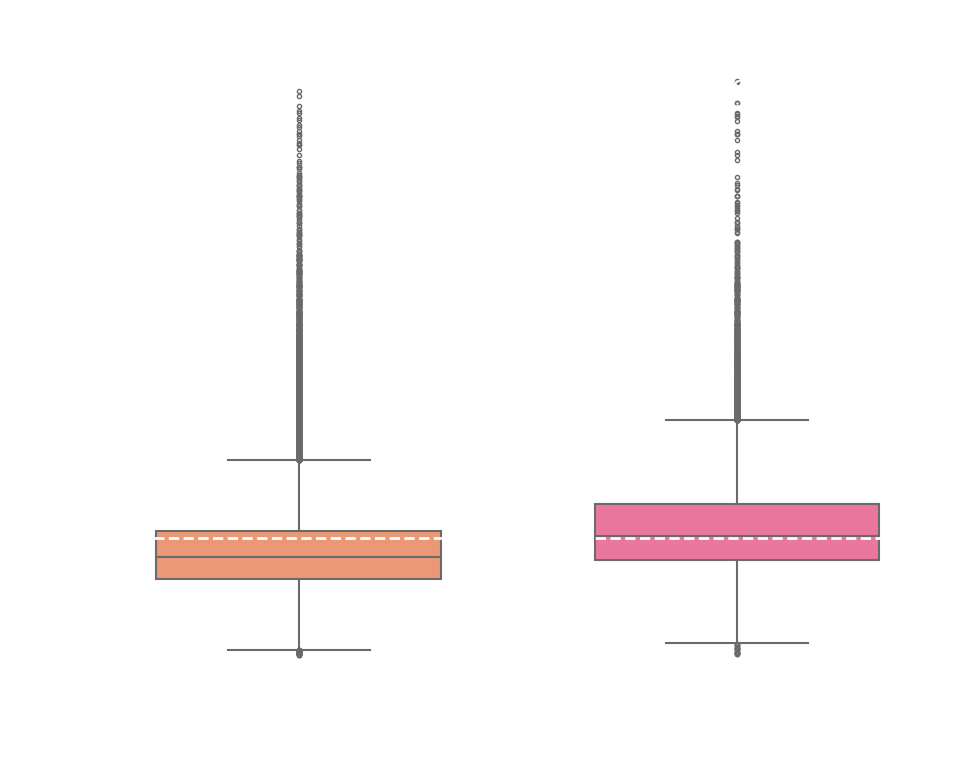

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.boxplot(
    data=df_eda,
    x='DIABETE4',
    y='_BMI5',
    palette=neon_colors[:2],
    width=0.65,
    linewidth=1.5,
    flierprops={"marker": "o", "markersize": 3, "alpha": 1},
    ax=ax
)

plt.title('Distribusi BMI Berdasarkan Status Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Status Diagnosis', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Body Mass Index (BMI)', fontsize=12, weight='bold', color='#FFFFFF')

plt.axhline(y=30, color='#FFFFFF', linestyle='--', linewidth=2, label='Batas Obesitas (BMI >= 30)')

plt.legend(facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', loc='upper right')

ax.grid(True, axis='y', color='#FFFFFF', alpha=0.15, linestyle='--')


plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_bmi_diabetes_boxplot_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_62019/2555817405.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(
/tmp/ipykernel_62019/2555817405.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxenplot(


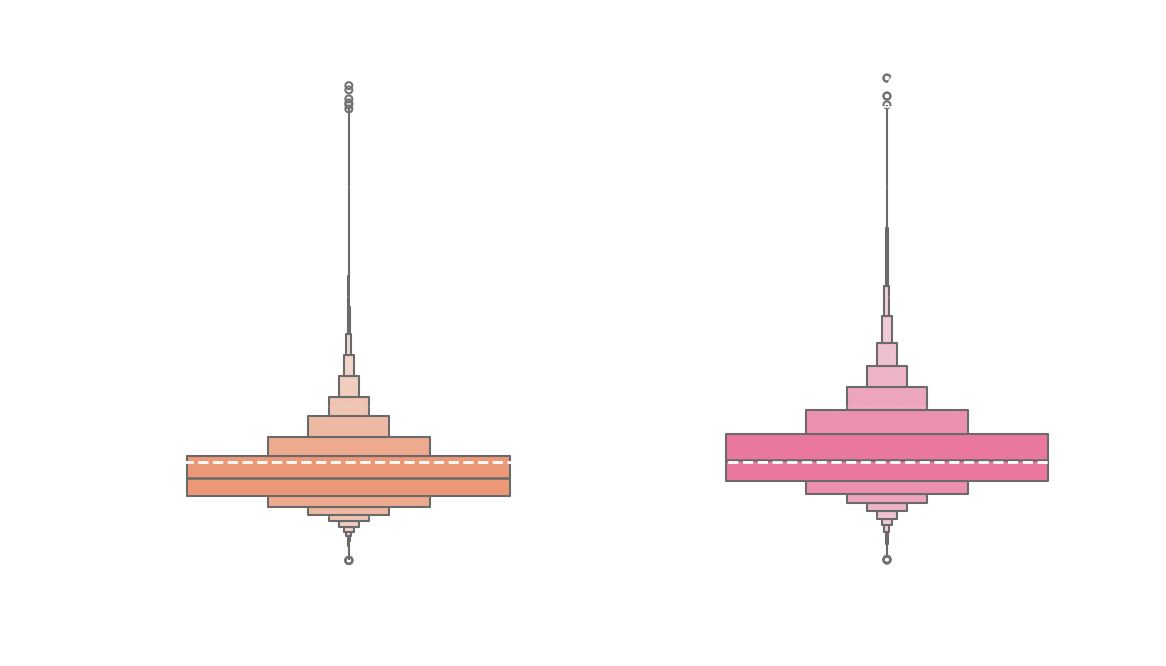

In [30]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.boxenplot(
    data=df_eda,
    x='DIABETE4',
    y='_BMI5',
    palette=neon_colors[:3],
    width=0.6,
    linewidth=1.5,
    ax=ax
)

plt.title('Distribusi Detail BMI Berdasarkan Status Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Status Diagnosis', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Body Mass Index (BMI)', fontsize=12, weight='bold', color='#FFFFFF')

plt.axhline(y=30, color='#FFFFFF', linestyle='--', linewidth=2, label='Batas Obesitas (BMI >= 30)')

plt.legend(facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', loc='upper right')

ax.grid(True, axis='y', color='#FFFFFF', alpha=0.1, linestyle='--')


plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_bmi_diabetes_boxen_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_62019/4084847490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(
/tmp/ipykernel_62019/4084847490.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxenplot(


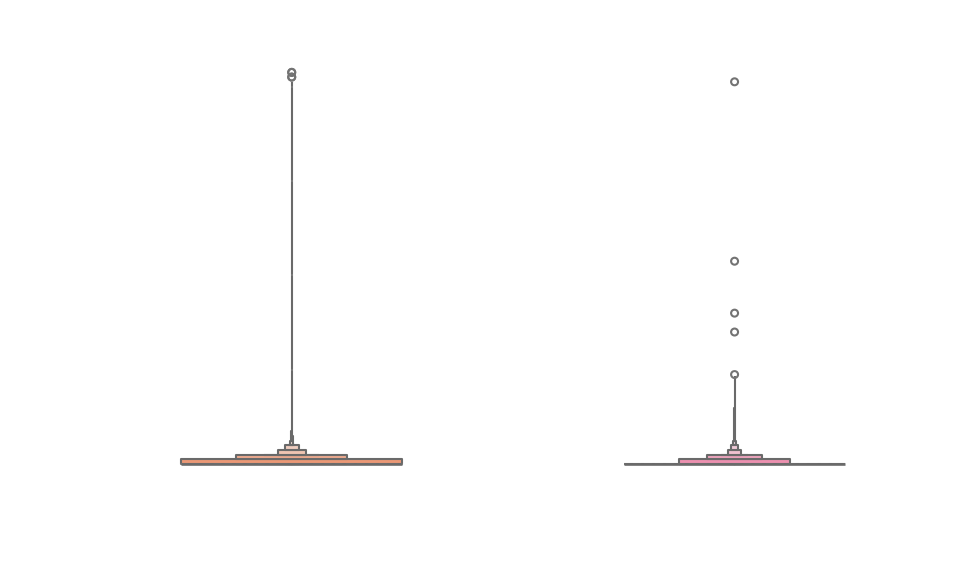

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxenplot(
    data=df_eda,
    x='DIABETE4',
    y='CHILDREN',
    palette=neon_colors[:3],
    width=0.5,
    linewidth=1.5,
    ax=ax
)

plt.title('Distribusi Jumlah Anak Berdasarkan Status Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Status Diagnosis', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Jumlah Anak', fontsize=12, weight='bold', color='#FFFFFF')


ax.grid(True, axis='y', color='#FFFFFF', alpha=0.1, linestyle='--')


plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_children_boxen_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()